In [ ]:
from skimage import measure, color
import numpy as np
import argparse
import imutils
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

## images

In [ ]:
led_img= "C:\\Users\\arite\\Desktop\\ASM RA\\ASM_Killifish_repo\\d48_65_s1.png"
no_led_img = "/Users/asmlabuser1/Scripts_Ari/no_led.png"

In [ ]:
led = cv2.cvtColor(cv2.imread(led_img), cv2.COLOR_BGR2RGB)
# no_led = cv2.cvtColor(cv2.imread(no_led_img), cv2.COLOR_BGR2RGB)
plt.imshow(led)

In [ ]:
print(led[0][0]) #pixel of normal image
led_LAB = color.rgb2lab(led)
# led_LAB = led
print(led_LAB[0][0])

In [ ]:
pixels = []
for i,y in enumerate(led_LAB):
    for j, x in enumerate(y):
        if x[0] > 35 and x[1] > 25 and -20<x[2]<40:
            pixels.append([i,j])
pixels_np = np.asarray(pixels)
print(pixels_np)

In [ ]:
mask = np.zeros((len(led), len(led[0])))
for [i,j] in pixels:
    mask[i][j] = 255
plt.imshow(mask)

In [ ]:
mask2 = cv2.dilate(mask2, None, iterations=1)
mask2 = cv2.erode(mask, None, iterations=3)

plt.imshow(mask2)

In [ ]:
print(no_led[0][0]) #pixel of normal image
no_led_LAB = color.rgb2lab(no_led)
print(no_led_LAB[0][0])

In [ ]:
pixels_no = []
for i,y in enumerate(no_led_LAB):
    for j, x in enumerate(y):
        if x[0] > 35 and x[1] > 25 and -20<x[2]<40:
            pixels_no.append([i,j])
# pixels_np_no = np.asarray(pixels_no)
# print(pixels_np)

In [ ]:
mask_no = np.zeros((1000,1600))
for [i,j] in pixels_no:
    mask_no[i][j] = 255
plt.imshow(mask_no)

In [ ]:
mask_no2 = cv2.erode(mask_no, None, iterations=3)
mask_no2 = cv2.dilate(mask_no2, None, iterations=8)
plt.imshow(mask_no2)

In [ ]:
led_img= "C:\\Users\\arite\\Desktop\\ASM RA\\ASM_Killifish_repo\\f1_noled.png"

led_LAB = cv2.cvtColor(cv2.imread(led_img), cv2.COLOR_BGR2LAB)
# led_LAB = color.rgb2lab(led)
plt.imshow(led_LAB)
and_mask = np.logical_and(led_LAB[:, :, 0] > 25, led_LAB[:, :, 1] > 25)
and_mask = np.logical_and(and_mask, np.logical_and(led_LAB[:, :, 2] > -20, led_LAB[:, :, 2] < 40))
pixels = np.argwhere(and_mask)

mask_bg = np.zeros((len(led_LAB), len(led_LAB[0])))
mask_bg[pixels[:, 0], pixels[:, 1]] = 255

# mask2 = cv2.dilate(mask_bw, None, iterations=3)
# mask_bg = cv2.erode(mask2, None, iterations=5)

plt.imshow(mask_bg)

In [ ]:
# %%timeit

led_img= "C:\\Users\\arite\\Desktop\\ASM RA\\ASM_Killifish_repo\\f1_led.png"
no_led_img = "C:\\Users\\arite\\Desktop\\ASM RA\\ASM_Killifish_repo\\f1_noled.png"
# led_LAB = cv2.cvtColor(cv2.imread(led_img), cv2.COLOR_BGR2Lab)
# led_LAB = cv2.cvtColor(cv2.imread(led_img), cv2.COLOR_BGR2Lab)

# plt.imshow(led_LAB)
# print(led_LAB[800][500])

# print(led_LAB[500][800])
# led_LAB = color.rgb2lab(led)

# and_mask = np.logical_and(led_LAB[:, :, 0] > 25, led_LAB[:, :, 1] > 25)
# and_mask = np.logical_and(and_mask, np.logical_and(led_LAB[:, :, 2] > -20, led_LAB[:, :, 2] < 40))

# pixels = np.argwhere(and_mask)
# lower_threshold = (25*2.55, 25+128, -20+128)
# upper_threshold = (100*2.55, 128+128, 40+128)
# mask = cv2.inRange(led_LAB, lower_threshold, upper_threshold)
# plt.imshow(mask)
led = create_mask(cv2.imread(led_img))
noled = create_mask(cv2.imread(no_led_img))
plt.imshow(led-noled)
# maskcv =  
# mask_bw = np.zeros((len(led_LAB), len(led_LAB[0])))
# mask_bw[pixels[:, 0], pixels[:, 1]] = 255
# mask_without_bg = mask_bw-mask_bg
# mask2 = cv2.dilate(mask_without_bg, None, iterations=3)
# mask_erode = cv2.erode(mask2, None, iterations=5)
print(np.count_nonzero(mask))
# plt.imshow(mask_erode)
# plt.imshow(mask_bw)

Work on videos + is some sort of verification needed??

## video
this section contains the current final implementation. we use video path to find all video files. LED_times array saves the final result for each video before saving that data in a csv. 

create_mask creates a mask given the image/frame. it converts frame to LAB color format and applies a small gaussian blur to decrease noise, before applying a threshold on L for luminance(brightness), and the other 2 channels for filtering the red color. 

the for loop is the main code. for each video, a progress bar is initiated. a capture object is opened to process each frame using opencv. bg flag tracks if a background mask has been created or not, which is done on the first frame. the small bg if loop stores the background mask in bg_mask variable and then turns flag to false. Next, we go through all the frames wherein a mask for the frame is created, after which we subtract background mask from the current frame's mask. we store all the timestamps at which LED is observed, and append the max and the min of this along with the video name to LED_times. After all the videos are processed, this array is saved to a csv in data/output folder

--vis flag is used to visualise background mask, and current mask while LED is detected. 

--video_path can be used to provide path to a folder containing videos if not in data/videos. 

--output_path can be used to provide output path for csv if not data/output






In [ ]:
vid_path=Path("./data/videos/")
# capture = cv2.VideoCapture(vid_path)
vid_list = list(vid_path.glob("*.mp4"))
# video = cv2.VideoCapture("d48_65_S1.mp4")
print(vid_list)
LED_times = [["name", "start time(s)", "end time(s)"]]
print(LED_times)

out_path = Path("./data/output/")
vis = False

In [ ]:
def get_timestamps(timestamps, debug = False):
    first_timestamp = None
    last_timestamp = None
    time_difference = 0
    final_timestamps = []
    for i, timestamp in enumerate(timestamps):
        if i == 0:
            first_timestamp = i
        else:
            time_difference += timestamp - timestamps[i - 1]
            print(f"time difference is {time_difference}") if debug else None

            if time_difference > 2500 and time_difference < 6000:
                last_timestamp = i
                print(f"replacing last timestamp to {timestamps[i]}") if debug else None

            elif time_difference >= 6000:
                if last_timestamp>first_timestamp:
                    print(f"replacing first timestamp with {timestamps[i]}, appending {timestamps[first_timestamp], timestamps[last_timestamp]}") if debug else None
                    final_timestamps.append([first_timestamp, last_timestamp])
                first_timestamp = i
                time_difference = 0
    
    if time_difference > 2500 and time_difference <6000 and [first_timestamp, last_timestamp] not in final_timestamps:
        final_timestamps.append([first_timestamp, last_timestamp])
        print(f"appending final timestamps {first_timestamp, last_timestamp}") if debug else None

    return final_timestamps


In [ ]:
def create_mask(frame):
  frame_LAB = cv2.cvtColor(cv2.GaussianBlur(frame,(5,5),0), cv2.COLOR_BGR2Lab)
  lower_threshold = (27*2.55, 25+128, -20+128)
  upper_threshold = (100*2.55, 128+128, 40+128)
  mask = cv2.inRange(frame_LAB, lower_threshold, upper_threshold)
  return mask

def process_video(video_path):
  video = cv2.VideoCapture(str(video_path))
  print(video_path.name)
  
  vis = True
  total_frames = int(video.get(cv2.CAP_PROP_FRAME_COUNT))
  progress_bar = tqdm(total=total_frames)
  
  time_for_video=[]
  bg = True
  mask_bg = []
  
  # Read until video is completed
  while(video.isOpened()):
    # Capture frame-by-frame
    ret, frame = video.read()

    if bg == True and ret == True:
      mask_bg = create_mask(frame)
      bg = False
      if vis == True: 
        cv2.imshow(f'{video_path.name} bg',mask_bg)
    if ret == True:  
      # Press Q on keyboard to  exit, for visualization
      if cv2.waitKey(25) & 0xFF == ord('q'):
        break
      
      mask_frame = create_mask(frame)
      mask_bw = mask_frame - mask_bg
      # print(time_for_video)
      #find number of non-zero pixels and print timestamp and pixels count if nonzero pixels > 2500
      if np.count_nonzero(mask_bw) > 2500:


        time_for_video.append(video.get(cv2.CAP_PROP_POS_MSEC))
        # print(min(time_for_video)) 
        # print timestamp of video frame
        # print(video.get(cv2.CAP_PROP_POS_MSEC))
        # EXPERIMENT IF ERODE AND DILATE IS NEEDED
        if vis == True:  
          mask_dilate = cv2.dilate(mask_bw, None, iterations=3)
          mask_erode = cv2.erode(mask_dilate, None, iterations=4)
          cv2.imshow(f'{video_path.name} mask',mask_erode)
      progress_bar.update(1)
    # Break the loop
    else: 
      break
    
  LED_times.append([video_path.name, min(time_for_video)/1000, max(time_for_video)/1000])
  # When everything done, release the video capture object, progress bar, and close frames
  
  video.release()
  progress_bar.close()
  cv2.destroyAllWindows()
  return time_for_video
  

# np.savetxt(out_path + "LED_times.csv",LED_times, delimiter=',', fmt = ["%s","%.2f", "%.2f"] )

In [ ]:
video.release()
progress_bar.close()
cv2.destroyAllWindows()


In [ ]:

timestamps = process_video(Path("/Users/asmlabuser1/Scripts_Ari/data/videos/143-160/problem_vids/156_M.mp4"))


In [ ]:
processed = timestamps[:-2]
print(processed)

processed_timestamps = get_timestamps(processed, debug = True)
print([(processed[i[0]], processed[i[1]]) for i in processed_timestamps])

In [ ]:
print(time_for_video)

In [ ]:
print(LED_times)
# print(time_for_video)
LED_times.append([str(video_path.name), "{:.2f}".format(min(time_for_video)/1000), "{:.2f}".format(max(time_for_video)/1000)])

In [ ]:
np.savetxt(Path(out_path, "LED_times.csv"),LED_times, delimiter=',', fmt = "%s" )

In [ ]:
!python ./scripts/LED_times.py --debug

In [ ]:
# movement of camera?

# # Load the two images
# image1 = cv2.imread("image1.jpg")
# image2 = cv2.imread("image2.jpg")
video = cv2.VideoCapture(str(video_path))

while (video.isOpened()):
    # Capture frame-by-frame
    ret, frame = video.read()
    if ret == True:
        
        # Convert the images to grayscale
        gray1 = cv2.cvtColor(image1, cv2.COLOR_BGR2GRAY)
        gray2 = cv2.cvtColor(image2, cv2.COLOR_BGR2GRAY)

        # Find the transformation matrix
        matrix, _ = cv2.findTransformECC(gray1, gray2, None, cv2.MOTION_AFFINE)

        # Check if the transformation is non-trivial
        if matrix is None or (matrix[0,2]**2 + matrix[1,2]**2) < 1e-10:
            print("Camera has not moved")
        else:
            print("Camera has moved")

In [ ]:
!python scripts/LED_times.py --video_path data/videos/143-160/problem_vids --debug

In [ ]:
# No LED found in ['146_M.mp4', '157_S.mp4', '153_S.mp4', '147_S.mp4', '144_F.mp4'] as none were present kinda vibe
# ones malfunction due to the higher threshold 148_t (not working at 25 also), 148_s, 159_m
# 147_F, 148_F is too jerky --> too many events (147_M moves at 10s)
# improved due to threshold 150_t 156_m 150_m (also code)
# improved due to delayed bg 148_t 148_s 159_m 154_f 156_m
# ?? 156_F - drifts after 10s, but led event is from 0?
# 152_S dunno how it got fixed, no detection to detection even tho increased threshold? maybe the delayed mask helped?
# troubleshoot from main 

In [ ]:
# for trying individual videos
import scripts.LED_times as LED_times_py
from pathlib import Path
LED_times = [["name", "start time(s)", "end time(s)", "start frame", "end frame"]]

problem_vids = {'Too many LED events': [], 'LED not observed': []}
debug = True
vis = False
max_LED = 2
video_path = Path("/Users/asmlabuser1/Scripts_Ari/data/videos/143-160/problem_vids/148_S.mp4")
LED_times_py.process_video(video_path, vis, debug, max_LED, LED_times, problem_vids, sensitive= True)


### experimenting with dynamic thresholding

Syntax: cv2.calcHist(images, channels, mask, histSize, ranges[, hist[, accumulate]])

Parameters:

images: list of images as numpy arrays. All images must be of the same dtype and same size.

channels: list of the channels used to calculate the histograms.

mask: optional mask (8 bit array) of the same size as the input image.

histSize: histogram sizes in each dimension

ranges: Array of the dims arrays of the histogram bin boundaries in each dimension

hist: Output histogram

accumulate: accumulation flag, enables to compute a single histogram from several sets of arrays.

Return: It returns an array of histogram points of dtype float32.



In [ ]:
# %%timeit
def create_mask(frame):
    frame_LAB = cv2.cvtColor(cv2.GaussianBlur(frame,(5,5),0), cv2.COLOR_BGR2Lab)
    lower_threshold = (0, 25+128, -20+128)
    upper_threshold = (100*2.55, 128+128, 40+128)
    mask_color = cv2.inRange(frame_LAB, lower_threshold, upper_threshold)

    # Calculate histogram of grayscale frame
    hist = cv2.calcHist([frame_LAB], [0], mask_color, [256], [0,256])
    min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(hist)
    threshold = max_loc[1]
    print(max_loc)
    print('threshold', threshold)

    # # Use threshold value to create lower and upper bounds for mask
    # lower_threshold = (35, 25+128, -20+128)
    # upper_threshold = (100*2.55, 128+128, 40+128)
    # mask = cv2.inRange(frame_LAB, lower_threshold, upper_threshold)
    # return mask


In [ ]:
# %%timeit
video = cv2.VideoCapture("data/videos/week_12/124-127/125_M.mp4")
ret, frame = video.read()
mask = create_mask(frame)
# plt.imshow(mask, cmap = 'gray')


In [ ]:
33.2, 34.9

In [ ]:
a = [1,2]
print(a[3]) if a[3] else print("no")

# how to check if index exists in list
a = [1,2]
if len(a) > 3:
    print(a[3])
else:
    

In [ ]:
%run -i scripts/LED_times.py --video_path data/videos/week_12/124-127/ --debug

In [1]:
%run -t scripts/LED_times.py --video_path data/videos/week_12/ --no_hist_thresh --output_path data/output/no_thresh/

 total videos found are 242
160_M.mp4


100%|██████████| 5400/5400 [03:16<00:00, 27.52it/s]


['160_M.mp4', '88.49', '93.46', 2653.0, 2802.0]
155_S.mp4


100%|██████████| 5400/5400 [03:13<00:00, 27.90it/s]


['155_S.mp4', '89.52', '93.26', 2684.0, 2796.0]
157_F.mp4


...

100%|██████████| 5400/5400 [03:22<00:00, 26.68it/s]


LED not observed in 149_M.mp4
147_T.mp4


100%|██████████| 5370/5370 [03:18<00:00, 27.02it/s]


['147_T.mp4', '90.59', '94.56', 2716.0, 2835.0]
158_S.mp4


  2%|▏         | 123/5700 [00:00<00:08, 622.43it/s]

### data integrity testing

In [121]:
import pandas as pd
import scipy
from math import sqrt
import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial.distance import pdist
# import pdist


df = pd.read_csv("./data/csv/test_csv_2.csv", header=None)
print(df.head(5))

          0        1         2                     3        4         5   \
0  bodyparts     Tail      Tail                  Tail    Body1     Body1   
1     coords        x         y            likelihood        x         y   
2          0  163.634  1483.663  0.017999999225139618  235.376   1508.42   
3          1  179.582  1483.663     0.843999981880188   235.38   1508.42   
4          2  179.582  1483.816     0.843999981880188  251.619  1508.424   

                    6        7         8                    9        10  \
0                Body1    Body2     Body2                Body2    Body3   
1           likelihood        x         y           likelihood        x   
2  0.08900000154972076  268.277  1539.849  0.13500000536441803  245.598   
3    0.972000002861023  339.957  1548.434   0.8550000190734863  389.703   
4    0.972000002861023  339.957  1548.434   0.8550000190734863  389.704   

         11                  12       13        14                  15  
0     Body3        

        1         2        4         5        7         8        10        11  \
2  163.634  1483.663  235.376  1508.420  268.277  1539.849  245.598  1524.037   
3  179.582  1483.663  235.380  1508.420  339.957  1548.434  389.703  1587.535   
4  179.582  1483.816  251.619  1508.424  339.957  1548.434  389.704  1587.541   
5  210.851  1483.818  251.619  1508.424  339.962  1548.435  434.881  1596.779   
6  237.959  1501.186  269.089  1513.974  366.271  1552.825  461.122  1604.914   

        13        14  
2  445.789  1620.403  
3  501.807  1644.302  
4  501.809  1644.303  
5  556.001  1660.611  
6  556.513  1683.082  
2574.3695
269


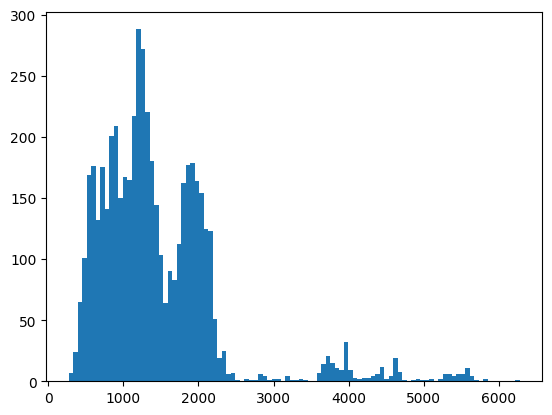

In [123]:
coords_df =  df.drop(df.columns[[0,3,6,9,12,15]], axis=1)
coords_df.drop([0,1], inplace=True)
coords_df = coords_df.astype(float)
print(coords_df.head(5))
problem_frames = []
fish_length = []
points_length = []
#iterate through rows to extract info
for row in coords_df.itertuples():
    x = [row[i] for i in range(1,10,2)]
    y = [row[i] for i in range(2,11,2)]
    points = np.array([[x[i], y[i]] for i in range(0, len(x))])
    distances = np.round(pdist(points, metric='euclidean'),2)
    fish_length.append(sum(distances))
    
    # print(x, y)
    # check if the points lie on a line
    # slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(x, y)
    # print(row[0], r_value) if abs(r_value) < 0.7 else None
    # problem_frames.add(row[0]) if abs(r_value) < 0.5 else None
    # length = sqrt((x[0]-x[-1])**2 + (y[0]-y[-1])**2)
    # fish_length.append(length) if length != 0 else None

# print (len(problem_frames))
# print(fish_length)
plt.hist(fish_length, bins = 100)
hist, bin_edges = np.histogram(fish_length, range = (0, max(fish_length)), bins = 100)
for i, prob in enumerate(hist):
    if prob == 0 and i > 10:
        break
print(bin_edges[i])
threshold = bin_edges[i]
# add frames with fish length greater than threshold to problem_frames
[problem_frames.append(i) for i, fish_length in enumerate(fish_length) if fish_length > threshold]
# problem_frames.add(i for i, fish_length in enumerate(fish_length) if fish_length > threshold)
print(len(problem_frames))



In [120]:
print(problem_frames)
print(len(coords_df))
print(len(problem_frames)*100/len(coords_df))

[303, 304, 305, 306, 307, 308, 309, 310, 311, 312, 313, 314, 471, 472, 479, 480, 481, 482, 483, 1231, 1232, 1234, 1235, 1236, 1497, 1498, 1499, 1604, 1605, 1606, 2337, 2338, 2339, 2386, 2778, 2779, 2780, 2781, 2785, 2786, 2787, 2788, 2789, 2790, 2791, 2792, 2802, 2803, 2804, 2805, 2807, 2808, 2809, 2810, 2811, 2812, 2814, 2815, 2816, 2817, 2818, 2819, 2820, 2821, 2822, 2823, 2824, 2908, 2909, 2910, 3280, 3285, 3295, 3296, 3431, 3437, 3438, 3440, 3441, 3442, 3443, 3444, 3447, 3448, 3449, 3450, 3451, 3452, 3453, 3454, 3455, 3456, 3458, 3459, 3460, 3461, 3462, 3463, 3464, 3465, 3466, 3467, 3468, 3469, 3470, 3472, 3485, 3486, 3487, 3488, 3491, 3492, 3493, 3494, 3495, 3496, 3497, 3498, 3499, 3500, 3501, 3502, 3503, 3504, 3505, 3506, 3507, 3508, 3509, 3510, 3511, 3512, 3513, 3514, 3515, 3516, 3517, 3518, 3519, 3520, 3521, 3522, 3523, 3524, 3525, 3526, 3531, 3532, 3533, 3534, 3535, 3536, 3537, 3538, 3542, 3543, 3544, 3545, 3546, 3547, 3548, 3549, 3550, 3551, 3552, 3553, 3554, 3555, 3556, 3557

3431,707.282,1113.594,0.9459999799728394,683.207,1116.825,0.9399999976158142,676.504,1164.183,0.6039999723434448,923.974,1907.849,0.15800000727176666,547.862,1915.972,0.026000000536441803


### testing find_coordinates

In [1]:
from scripts.LED_times import *
import pandas as pd
import numpy as np

video_path = Path("./data/videos/week_12/143-160/")
# def process_video(video_path, vis, debug, max_LED, LED_times, problem_vids,hist_thresh, sensitive = False ):
# for video in video_path.parent.glob("*.mp4"):
for video in video_path.glob("*.mp4"):
    print(video)
    LED_times = [["name", "start time(s)", "end time(s)", "start frame", "end frame"]]
    problem_vids = {'Too many LED events': [], 'LED not observed': []}
    debug = False
    vis = False
    max_LED = 2
    hist_thresh = False
    process_video(video, vis = False, debug = False, max_LED = 2, LED_times = [], problem_vids = [], hist_thresh= False,sensitive = True)


data/videos/week_12/143-160/160_M.mp4
160_M.mp4


 49%|████▉     | 2655/5400 [01:39<01:49, 25.04it/s]

(541, 540)


100%|██████████| 5400/5400 [03:26<00:00, 26.10it/s]


['160_M.mp4', '88.49', '93.46', 2653.0, 2802.0, 541, 540]
data/videos/week_12/143-160/155_S.mp4
155_S.mp4


...

(413, 698)


100%|██████████| 5400/5400 [03:29<00:00, 25.81it/s]


['144_M.mp4', '90.29', '94.26', 2707.0, 2826.0, 413, 698]
data/videos/week_12/143-160/146_M.mp4
146_M.mp4


100%|██████████| 5400/5400 [03:29<00:00, 25.76it/s]


TypeError: list indices must be integers or slices, not str

In [1]:
%run scripts/LED_times.py --video_path data/videos/d48_test/ --no_hist_thresh --output_path data/output/d48_test_coords/

 total videos found are 4
d48_35_F1.mp4


100%|██████████| 5460/5460 [03:27<00:00, 26.36it/s]


['d48_35_F1.mp4', '87.79', '92.76', 2632.0, 2781.0, 322, 570]
d48_23_T3.mp4


100%|██████████| 5370/5370 [03:23<00:00, 26.42it/s]


LED not observed in d48_23_T3.mp4
d48_65_S1.mp4


...

LED not observed in d48_23_T3.mp4
failed to process d48_23_T3.mp4
running reduced threshold analysis for d48_65_S1.mp4
d48_65_S1.mp4


100%|██████████| 5490/5490 [03:28<00:00, 26.38it/s]


LED not observed in d48_65_S1.mp4
failed to process d48_65_S1.mp4
running reduced threshold analysis for d48_61_T1.mp4
d48_61_T1.mp4


100%|██████████| 3600/3600 [02:11<00:00, 27.40it/s]

['d48_61_T1.mp4', '60.43', '65.33', 1812.0, 1959.0, 535, 819]
successfully processed d48_61_T1.mp4
problems found in {'Too many LED events': [], 'LED not observed': ['d48_23_T3.mp4', 'd48_65_S1.mp4']}, after running reduced threshold analysis
saving to data/output/d48_test_coords/LED_times.csv


In [2]:
%run scripts/LED_times.py --video_path data/videos/week_12/ --output_path data/output/week_12_coords/ --no_hist_thresh

 total videos found are 242
160_M.mp4


100%|██████████| 5400/5400 [03:23<00:00, 26.56it/s]


['160_M.mp4', '88.49', '93.46', 2653.0, 2802.0, 541, 540]
155_S.mp4


100%|██████████| 5400/5400 [03:25<00:00, 26.31it/s]


['155_S.mp4', '89.52', '93.26', 2684.0, 2796.0, 244, 272]
157_F.mp4


...

100%|██████████| 5580/5580 [03:32<00:00, 26.26it/s]


LED not observed in 153_S.mp4
155_T.mp4


100%|██████████| 5370/5370 [03:25<00:00, 26.18it/s]


['155_T.mp4', '88.39', '92.36', 2650.0, 2769.0, 296, 466]
148_F.mp4


 95%|█████████▌| 5176/5422 [03:17<00:09, 26.93it/s]